# Setup

In [11]:
# ─────────────────────────────────────────────
# 01_data_processing.ipynb
#
# Purpose:
#   Load MedMCQA, clean explanations, build
#   knowledge base and QA pair structures.
#
# Outputs (skipped if already exist):
#   data/train_qa.pkl
#   data/val_qa.pkl
#   data/test_qa.pkl
#   data/full_kb_docs.pkl
#   data/cleaned_kb_docs.pkl
#   data/val_eval_mcq.pkl
#   data/val_tune_mcq.pkl
#   data/test_mcq.pkl
# ─────────────────────────────────────────────

!pip install datasets sentence-transformers -q

import os
import sys
import pickle
import numpy as np
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MedQA_Project"
# Ensure BASE is an absolute and normalized path
BASE = os.path.abspath(os.path.realpath(BASE))

# Ensure the project base directory is at the front of sys.path
# This aggressively places it first, removing any duplicate entries.
if BASE in sys.path:
    sys.path.remove(BASE)
sys.path.insert(0, BASE)

# Aggressively clear any existing module references to force re-import
# This is a common workaround for stubborn ModuleNotFoundErrors in notebooks
if 'src.data_processing' in sys.modules:
    del sys.modules['src.data_processing']
if 'src' in sys.modules:
    del sys.modules['src']
# Also handle the possibility of just 'data_processing' if it was tried directly
if 'data_processing' in sys.modules:
    del sys.modules['data_processing']

from src.config import (
    DATA_DIR, ensure_dirs,
    TRAIN_QA_PATH, VAL_QA_PATH, TEST_QA_PATH,
    FULL_KB_DOCS_PATH, CLEANED_KB_PATH,
    VAL_EVAL_MCQ_PATH, VAL_TUNE_MCQ_PATH,
    TEST_MCQ_PATH,
)
from src.data_processing import (
    load_medmcqa, build_project_dataset,
    build_mcq_dataset_from_raw, clean_knowledge_base,
    split_validation_set, subject_distribution,
    save_pkl, load_pkl,
)

ensure_dirs()
print("Setup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete


# Load or build base QA splits

In [12]:
# ─────────────────────────────────────────────
# Load MedMCQA and build QA pairs + KB docs
# Skips if pkl files already exist
# ─────────────────────────────────────────────

if (os.path.exists(TRAIN_QA_PATH) and
    os.path.exists(VAL_QA_PATH)   and
    os.path.exists(TEST_QA_PATH)  and
    os.path.exists(FULL_KB_DOCS_PATH)):

    print("Base splits already exist — loading from Drive\n")
    train_qa       = load_pkl(TRAIN_QA_PATH,      "train_qa")
    val_qa         = load_pkl(VAL_QA_PATH,        "val_qa")
    test_qa        = load_pkl(TEST_QA_PATH,       "test_qa")
    full_kb_docs   = load_pkl(FULL_KB_DOCS_PATH,  "full_kb_docs")

else:
    print("Building base splits from MedMCQA...\n")
    dataset = load_medmcqa()

    train_docs, train_qa = build_project_dataset(
        dataset['train'],      "Train")
    val_docs,   val_qa   = build_project_dataset(
        dataset['validation'], "Validation")
    test_docs,  test_qa  = build_project_dataset(
        dataset['test'],       "Test")

    # Knowledge base = train + val docs
    full_kb_docs = train_docs + val_docs
    print(f"\nFull KB: {len(full_kb_docs):,} documents")

    # Save
    print("\nSaving...")
    save_pkl(train_qa,     TRAIN_QA_PATH,     "train_qa")
    save_pkl(val_qa,       VAL_QA_PATH,       "val_qa")
    save_pkl(test_qa,      TEST_QA_PATH,      "test_qa")
    save_pkl(full_kb_docs, FULL_KB_DOCS_PATH, "full_kb_docs")

print(f"\nSizes:")
print(f"  train_qa:     {len(train_qa):,}")
print(f"  val_qa:       {len(val_qa):,}")
print(f"  test_qa:      {len(test_qa):,}")
print(f"  full_kb_docs: {len(full_kb_docs):,}")

Base splits already exist — loading from Drive

  Loaded train_qa
  Loaded val_qa
  Loaded test_qa
  Loaded full_kb_docs

Sizes:
  train_qa:     182,822
  val_qa:       4,183
  test_qa:      6,150
  full_kb_docs: 156,555


# Clean knowledge base

In [13]:
# ─────────────────────────────────────────────
# Apply text cleaning to knowledge base docs
# Removes exam prefixes, reference citations,
# asterisks, and normalises whitespace
# ─────────────────────────────────────────────

if os.path.exists(CLEANED_KB_PATH):
    print("Cleaned KB already exists — loading\n")
    cleaned_kb_docs = load_pkl(CLEANED_KB_PATH, "cleaned_kb_docs")
else:
    print("Cleaning knowledge base...\n")
    cleaned_kb_docs, stats = clean_knowledge_base(full_kb_docs)
    save_pkl(cleaned_kb_docs, CLEANED_KB_PATH, "cleaned_kb_docs")

print(f"Cleaned KB size: {len(cleaned_kb_docs):,}")

# Verify a cleaned example
print("\nCleaning example:")
for i in range(len(full_kb_docs)):
    orig    = full_kb_docs[i]['text']
    cleaned = cleaned_kb_docs[i]['text']
    if orig != cleaned:
        print(f"  Before: {orig[:100]}...")
        print(f"  After:  {cleaned[:100]}...")
        break

Cleaned KB already exists — loading

  Loaded cleaned_kb_docs
Cleaned KB size: 156,555

Cleaning example:
  Before: Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnan...
  After:  Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnan...


# Build MCQ datasets (with options)

In [14]:
# ─────────────────────────────────────────────
# Build MCQ datasets that include all 4 options
# These are needed for MCQ evaluation
# ─────────────────────────────────────────────

if (os.path.exists(VAL_EVAL_MCQ_PATH) and
    os.path.exists(VAL_TUNE_MCQ_PATH) and
    os.path.exists(TEST_MCQ_PATH)):

    print("MCQ splits already exist — loading\n")
    val_eval_mcq = load_pkl(VAL_EVAL_MCQ_PATH, "val_eval_mcq")
    val_tune_mcq = load_pkl(VAL_TUNE_MCQ_PATH, "val_tune_mcq")
    test_mcq     = load_pkl(TEST_MCQ_PATH,     "test_mcq")

else:
    print("Building MCQ splits from MedMCQA...\n")

    # Need raw dataset
    try:
        dataset
    except NameError:
        dataset = load_medmcqa()

    val_mcq_full = build_mcq_dataset_from_raw(
        dataset['validation'], "Validation")
    test_mcq     = build_mcq_dataset_from_raw(
        dataset['test'], "Test")

    # Split validation 50/50: tune | eval
    val_tune_mcq, val_eval_mcq = split_validation_set(
        val_mcq_full, seed=42)

    save_pkl(val_eval_mcq, VAL_EVAL_MCQ_PATH, "val_eval_mcq")
    save_pkl(val_tune_mcq, VAL_TUNE_MCQ_PATH, "val_tune_mcq")
    save_pkl(test_mcq,     TEST_MCQ_PATH,     "test_mcq")

print(f"\nMCQ split sizes:")
print(f"  val_eval_mcq: {len(val_eval_mcq):,}")
print(f"  val_tune_mcq: {len(val_tune_mcq):,}")
print(f"  test_mcq:     {len(test_mcq):,}")

MCQ splits already exist — loading

  Loaded val_eval_mcq
  Loaded val_tune_mcq
  Loaded test_mcq

MCQ split sizes:
  val_eval_mcq: 2,092
  val_tune_mcq: 2,091
  test_mcq:     6,150


# Subject distribution analysis

Subject                              KB Docs  Eval Qs    Ratio
-----------------------------------------------------------------
Medicine                              14,662      161     91.1x
Surgery                               14,362      191     75.2x
Anatomy                               13,540      112    120.9x
Pathology                             12,579      171     73.6x
Pharmacology                          11,139      123     90.6x
Social & Preventive Medicine          10,144       61    166.3x
Microbiology                           9,808       63    155.7x
Gynaecology & Obstetrics               8,830      109     81.0x
Physiology                             8,154       82     99.4x
Pediatrics                             7,816      122     64.1x
Biochemistry                           7,755       94     82.5x
Ophthalmology                          6,370       26    245.0x
Forensic Medicine                      4,949       27    183.3x
ENT                                    

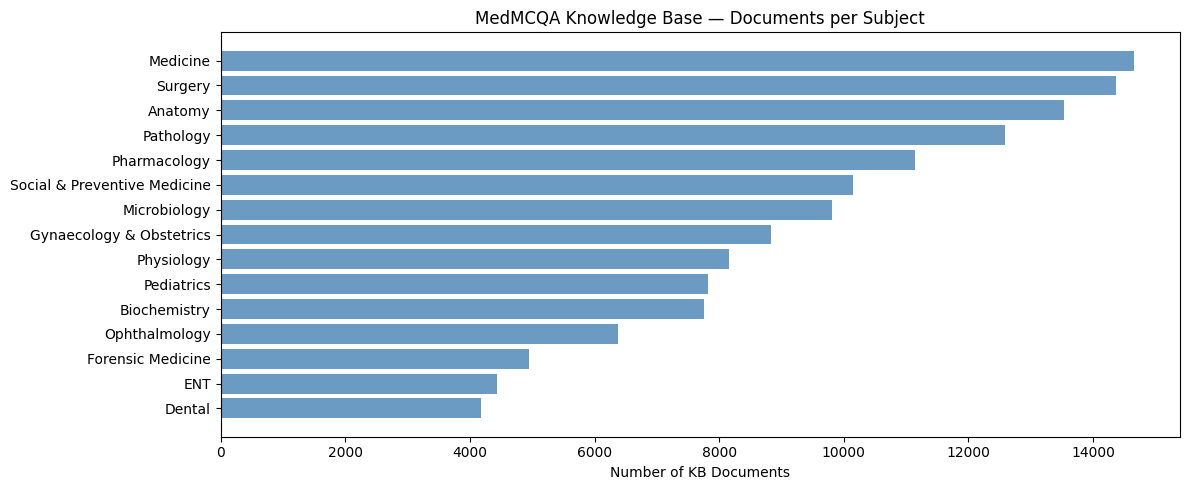

Chart saved


In [15]:
# ─────────────────────────────────────────────
# Analyse subject distribution in KB and eval set
# This is informational — guides understanding
# of which subjects have sparse coverage
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt

kb_subjects   = subject_distribution(cleaned_kb_docs)
eval_subjects = subject_distribution(val_eval_mcq)

print(f"{'Subject':<35} {'KB Docs':>8} {'Eval Qs':>8} {'Ratio':>8}")
print("-" * 65)

for subject, kb_count in list(kb_subjects.items())[:20]:
    eval_count = eval_subjects.get(subject, 0)
    ratio      = kb_count / max(eval_count, 1)
    print(f"{subject:<35} {kb_count:>8,} "
          f"{eval_count:>8,} {ratio:>8.1f}x")

# Bar chart
subjects = list(kb_subjects.keys())[:15]
counts   = [kb_subjects[s] for s in subjects]

plt.figure(figsize=(12, 5))
plt.barh(subjects[::-1], counts[::-1],
         color='steelblue', alpha=0.8)
plt.xlabel("Number of KB Documents")
plt.title("MedMCQA Knowledge Base — Documents per Subject")
plt.tight_layout()
plt.savefig(f"{BASE}/results/subject_distribution.png",
            dpi=150)
plt.show()
print("Chart saved")

In [16]:
# ─────────────────────────────────────────────
# Generate KB embeddings if not already present
# This is normally done in Notebook 02 but
# leakage detection needs them here first
# ─────────────────────────────────────────────

from src.config import KB_EMBEDDINGS_PATH
from src.models import load_retriever
from src.knowledge_base import generate_embeddings

if os.path.exists(KB_EMBEDDINGS_PATH):
    print("KB embeddings already exist — skipping generation")
    print(f"  Path: {KB_EMBEDDINGS_PATH}")
else:
    print("KB embeddings not found — generating now...")
    print(f"  Docs: {len(cleaned_kb_docs):,}")
    print("  Expected time: 20-30 minutes on Colab GPU\n")

    try:
        retriever
    except NameError:
        retriever = load_retriever()

    kb_texts = [doc['text'] for doc in cleaned_kb_docs]

    kb_embeddings = generate_embeddings(
        kb_texts,
        retriever,
        batch_size=256,
        show_progress=True,
    )

    print(f"\nEmbeddings shape: {kb_embeddings.shape}")
    np.save(KB_EMBEDDINGS_PATH, kb_embeddings)
    size_mb = os.path.getsize(KB_EMBEDDINGS_PATH) / (1024**2)
    print(f"Saved: {size_mb:.0f} MB")

# Load for use in leakage detection
kb_embs = np.load(KB_EMBEDDINGS_PATH)
print(f"\nKB embeddings loaded: {kb_embs.shape}")

KB embeddings already exist — skipping generation
  Path: /content/drive/MyDrive/MedQA_Project/data/kb_embeddings_cleaned.npy

KB embeddings loaded: (156555, 384)


# Leakage detection

In [17]:
# ─────────────────────────────────────────────
# Detect potential data leakage between
# evaluation questions and knowledge base
#
# Method: cosine similarity between question
# embedding and all KB doc embeddings
# Threshold 0.92 flags near-identical pairs
# ─────────────────────────────────────────────

from src.config import (
    LEAKAGE_RESULTS_PATH, SIMILARITY_LEAK_THR,
    KB_EMBEDDINGS_PATH,
)
from src.models import load_retriever
from src.data_processing import save_pkl, load_pkl

CLEAN_TEST_MCQ_PATH = f"{DATA_DIR}/clean_test_mcq.pkl"

# Check if leakage results exist AND if they are for the correct dataset (val_eval_mcq)
# If not, or if the file doesn't exist, re-compute them.
if (os.path.exists(LEAKAGE_RESULTS_PATH) and
    len(load_pkl(LEAKAGE_RESULTS_PATH)) == len(val_eval_mcq)):
    print("Leakage results already exist and match val_eval_mcq — loading\n")
    leakage_results = load_pkl(LEAKAGE_RESULTS_PATH, "leakage_results")
else:
    if os.path.exists(LEAKAGE_RESULTS_PATH):
        print("Existing leakage results do not match val_eval_mcq, recomputing...\n")
    else:
        print("Running leakage detection...\n")

    retriever = load_retriever()

    # Embed test questions
    test_questions = [qa['question']
                       for qa in val_eval_mcq]
    print("Embedding evaluation questions...")
    test_embs = retriever.encode(
        test_questions,
        batch_size=256,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True,
    )

    # Load KB embeddings
    kb_embs = np.load(KB_EMBEDDINGS_PATH)
    print(f"KB embeddings: {kb_embs.shape}")

    # Compute max similarity per question
    leakage_results = []
    batch_size = 500
    for i in range(0, len(test_embs), batch_size):
        batch    = test_embs[i:i+batch_size]
        sims     = np.dot(batch, kb_embs.T)
        top_idxs = np.argmax(sims, axis=1)
        top_sims = sims[np.arange(len(batch)), top_idxs]

        for j, (max_sim, top_idx) in enumerate(
                zip(top_sims, top_idxs)):
            q_idx = i + j
            leakage_results.append({
                "query_id":      val_eval_mcq[q_idx]['id'],
                "question":      val_eval_mcq[q_idx]['question'],
                "subject":       val_eval_mcq[q_idx]['subject'],
                "max_similarity":float(max_sim),
                "is_leak":       float(max_sim) >= SIMILARITY_LEAK_THR,
            })

    save_pkl(leakage_results,
             LEAKAGE_RESULTS_PATH, "leakage_results")

# Summary
leaked = [r for r in leakage_results if r['is_leak']]
clean  = [r for r in leakage_results if not r['is_leak']]

print(f"\nLeakage Summary:")
print(f"  Total:   {len(leakage_results):,}")
print(f"  Leaked:  {len(leaked):,} "
      f"({len(leaked)/len(leakage_results)*100:.1f}%)")
print(f"  Clean:   {len(clean):,} "
      f"({len(clean)/len(leakage_results)*100:.1f}%)")

# Save clean MCQ set (leaked questions removed)
clean_ids    = {r['query_id'] for r in clean}
clean_test   = [qa for qa in val_eval_mcq
                 if qa['id'] in clean_ids]

save_pkl(clean_test, CLEAN_TEST_MCQ_PATH, "clean_test_mcq")
print(f"\nClean eval set: {len(clean_test):,} questions")

  Loaded leakage_results.pkl
Leakage results already exist and match val_eval_mcq — loading

  Loaded leakage_results

Leakage Summary:
  Total:   2,092
  Leaked:  7 (0.3%)
  Clean:   2,085 (99.7%)
  Saved clean_test_mcq: 0.5 MB

Clean eval set: 2,085 questions


#  Final verification

In [18]:
# ─────────────────────────────────────────────
# Verify all outputs exist and are correct size
# ─────────────────────────────────────────────

checks = [
    (TRAIN_QA_PATH,     "train_qa",       182_000, None),
    (VAL_QA_PATH,       "val_qa",         4_000,   None),
    (TEST_QA_PATH,      "test_qa",        6_000,   None),
    (FULL_KB_DOCS_PATH, "full_kb_docs",   155_000, None),
    (CLEANED_KB_PATH,   "cleaned_kb_docs",155_000, None),
    (VAL_EVAL_MCQ_PATH, "val_eval_mcq",   1_000,   None),
    (VAL_TUNE_MCQ_PATH, "val_tune_mcq",   1_000,   None),
    (TEST_MCQ_PATH,     "test_mcq",       6_000,   None),
    (CLEAN_TEST_MCQ_PATH,"clean_test_mcq",1_000,   None),
    (LEAKAGE_RESULTS_PATH,"leakage",      1_000,   None),
]

print("NOTEBOOK 01 — FINAL VERIFICATION\n")
print(f"{'File':<25} {'Exists':>7} {'Size MB':>9} {'Records':>9}")
print("-" * 55)

all_ok = True
for path, label, min_records, _ in checks:
    exists  = os.path.exists(path)
    size_mb = os.path.getsize(path)/(1024**2) if exists else 0

    if exists:
        with open(path, "rb") as f:
            obj = pickle.load(f)
        n = len(obj)
        ok = n >= min_records
    else:
        n  = 0
        ok = False

    if not ok:
        all_ok = False

    status = "✅" if ok else "❌"
    print(f"{label:<25} {status:>7}  "
          f"{size_mb:>8.1f}  {n:>9,}")

print()
if all_ok:
    print("All checks passed ✅")
    print("Ready for Notebook 02 — Build Index")
else:
    print("Some checks failed ❌ — review above")

NOTEBOOK 01 — FINAL VERIFICATION

File                       Exists   Size MB   Records
-------------------------------------------------------
train_qa                        ✅      32.2    182,822
val_qa                          ✅       0.7      4,183
test_qa                         ✅       0.9      6,150
full_kb_docs                    ✅      93.6    156,555
cleaned_kb_docs                 ✅      86.1    156,555
val_eval_mcq                    ✅       0.5      2,092
val_tune_mcq                    ✅       0.5      2,091
test_mcq                        ✅       1.3      6,150
clean_test_mcq                  ✅       0.5      2,085
leakage                         ✅       0.3      2,092

All checks passed ✅
Ready for Notebook 02 — Build Index
